In [1]:
import seaborn as sns
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pylab as plt
from kneed import KneeLocator

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df_clean = df.drop("CustomerID", axis=1)
df_clean

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


# Data Visualization

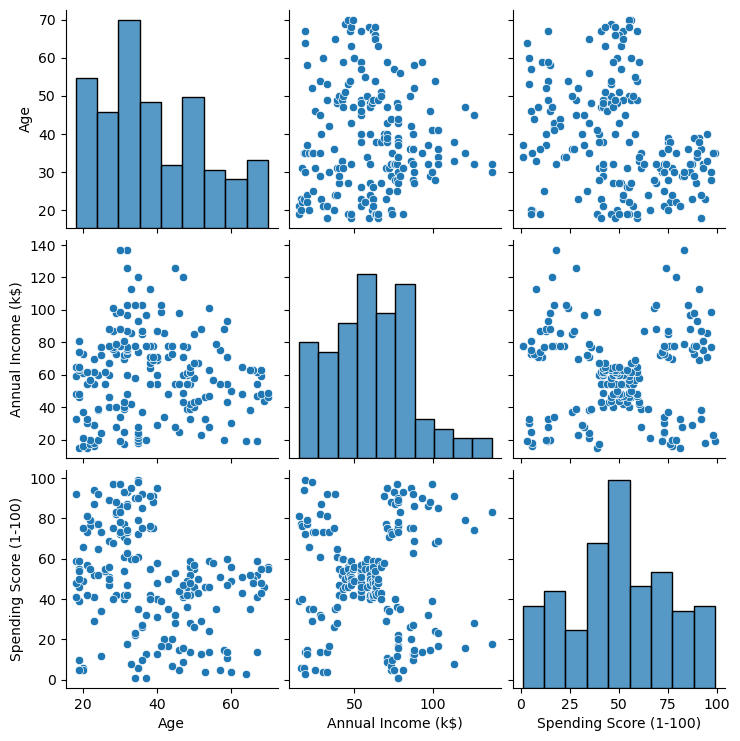

In [5]:
sns.pairplot(df_clean)

<Axes: xlabel='Age', ylabel='Count'>

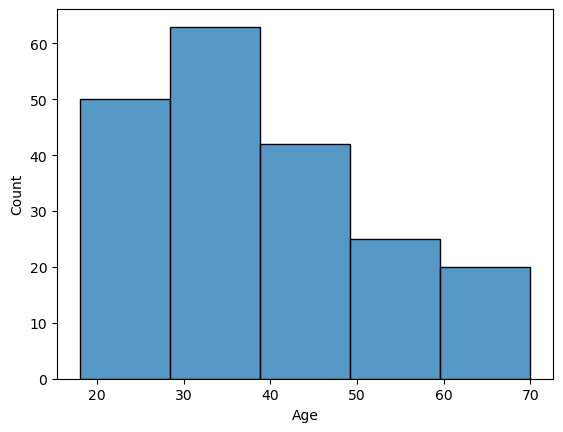

In [6]:
sns.histplot(df["Age"], bins=5)

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

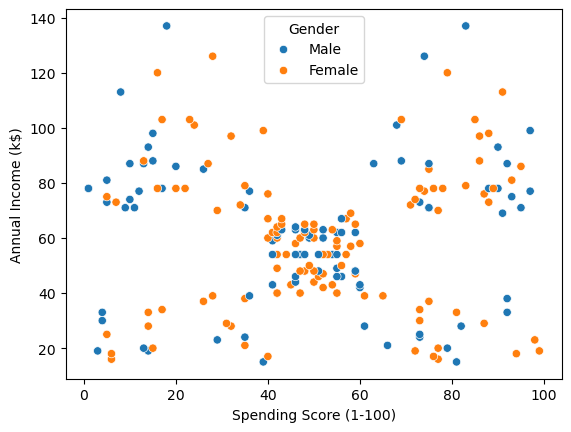

In [7]:
# Spending score vs gender

sns.scatterplot(x=df["Spending Score (1-100)"], y=df["Annual Income (k$)"], hue=df["Gender"])

<Axes: xlabel='Gender', ylabel='Annual Income (k$)'>

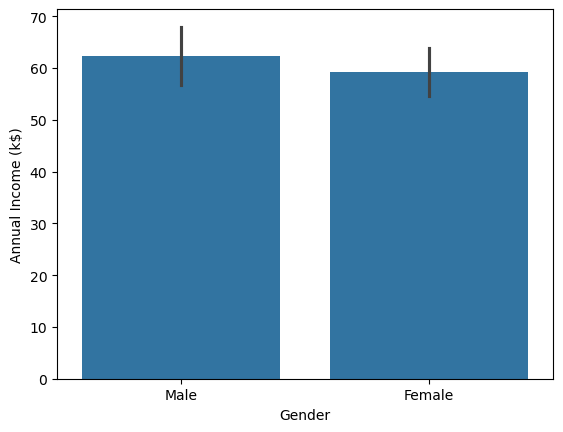

In [8]:
# income vs gender

sns.barplot(x=df["Gender"], y=df["Annual Income (k$)"])

<Axes: ylabel='Annual Income (k$)'>

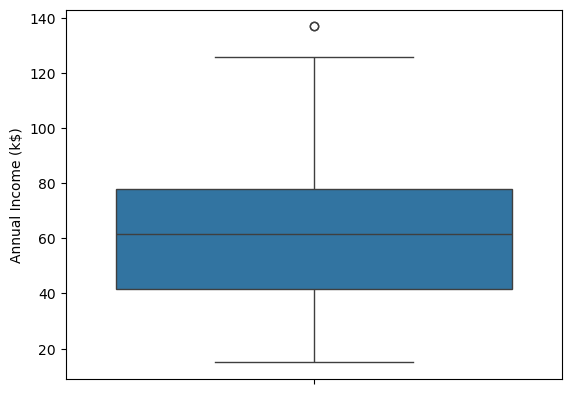

In [9]:
sns.boxplot(df["Annual Income (k$)"])

<Axes: ylabel='Spending Score (1-100)'>

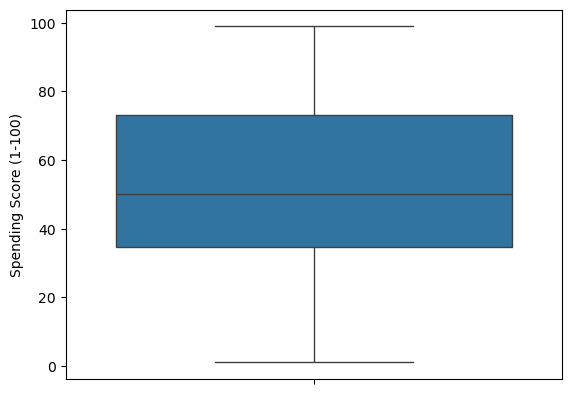

In [10]:
sns.boxplot(df["Spending Score (1-100)"])

In [11]:
# drop outlier

print("data size with outliers:",len(df_clean))

df_clean = df_clean[df_clean["Annual Income (k$)"] < 120]

print("data size without outliers:", len(df_clean))

data size with outliers: 200
data size without outliers: 194


# Encoding & Heatmap

In [12]:
df_clean["Gender"] = df_clean["Gender"].map({
    "Male" : 1,
    "Female" : 0
})

df_clean.head()

C:\Users\prita\AppData\Local\Temp\ipykernel_22688\2950028784.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Gender"] = df_clean["Gender"].map({


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [13]:
corr = df_clean.corr()
corr

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Gender,1.000000,0.074777,0.045913,-0.070667
Age,0.074777,1.000000,0.001700,-0.324235
Annual Income (k$),0.045913,0.001700,1.000000,0.012831
Spending Score (1-100),-0.070667,-0.324235,0.012831,1.000000


<Axes: >

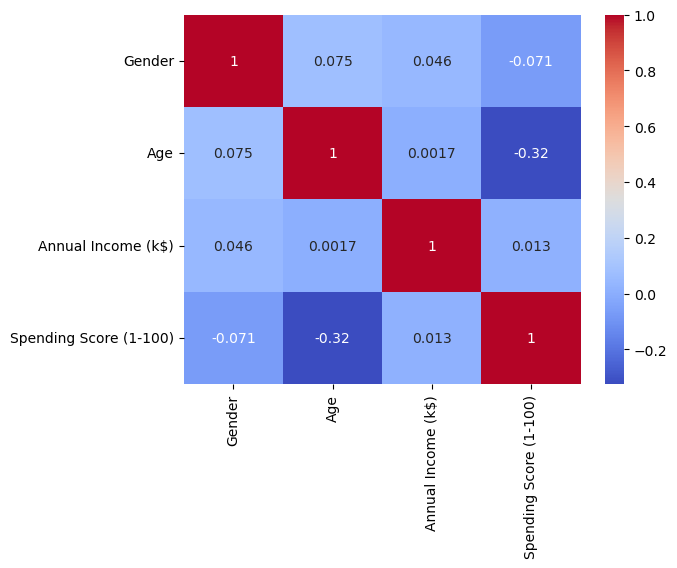

In [14]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [15]:
# Scaling

scaler = StandardScaler()

df_scal = scaler.fit_transform(df_clean)

In [16]:
# dimensionality reduciton using PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(df_scal)

In [17]:
pca.explained_variance_ratio_

array([0.33854641, 0.25848026, 0.23411517])

Text(0.5, 0.92, '3d projection')

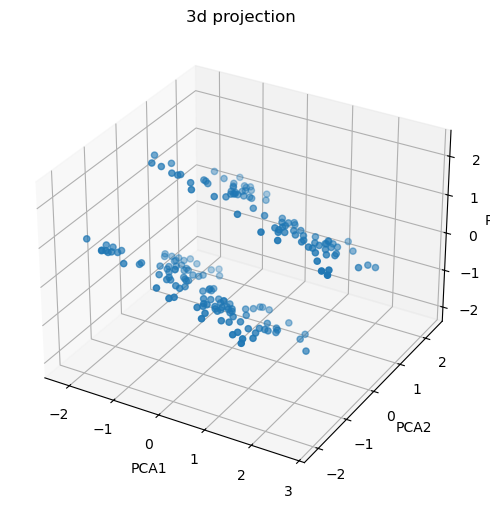

In [18]:
# Visualization

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value

In [19]:
# Elbow method

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

In [20]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print("best k =", optimal_k)

best k = 5


Text(0, 0.5, 'WCSS')

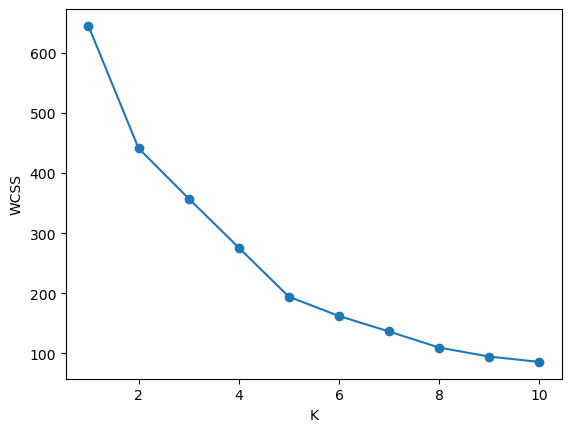

In [21]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

In [22]:
# Silhouette Score

ss = []

for k in range(2, 10):
    Kmeans = KMeans(n_clusters=k)
    labels = Kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    ss.append(score)

c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

<Axes: >

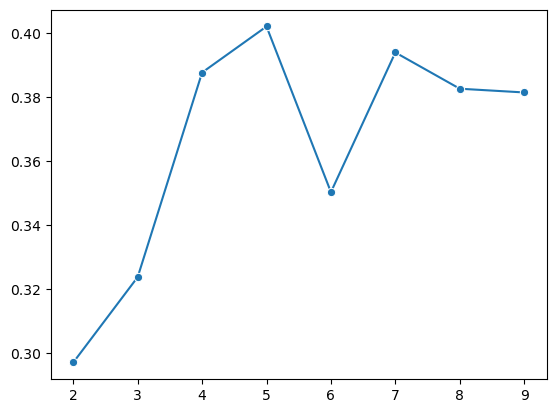

In [23]:
sns.lineplot(x=range(2, 10), y=ss, marker = "o")

c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 0.92, '3d projection')

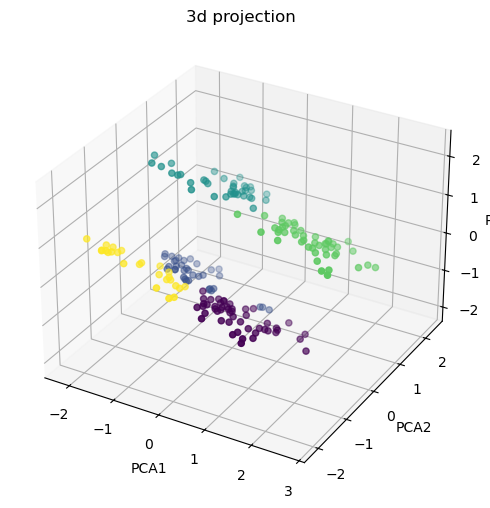

In [24]:
# KMeans

Kmeans = KMeans(n_clusters=5, random_state=42)
labels = Kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [25]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [26]:
agg_cls = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_agg = agg_cls.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

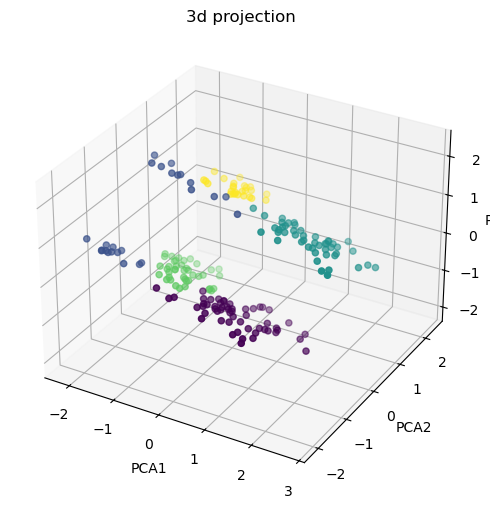

In [27]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels_agg)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [32]:
X = df_clean

In [37]:
X["cluster"] = labels

C:\Users\prita\AppData\Local\Temp\ipykernel_22688\2816585894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["cluster"] = labels


In [38]:
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,cluster
0,1,19,15,39,2,2
1,1,21,15,81,2,2
2,0,20,16,6,4,4
3,0,23,16,77,4,4
4,0,31,17,40,4,4


<Axes: xlabel='cluster', ylabel='count'>

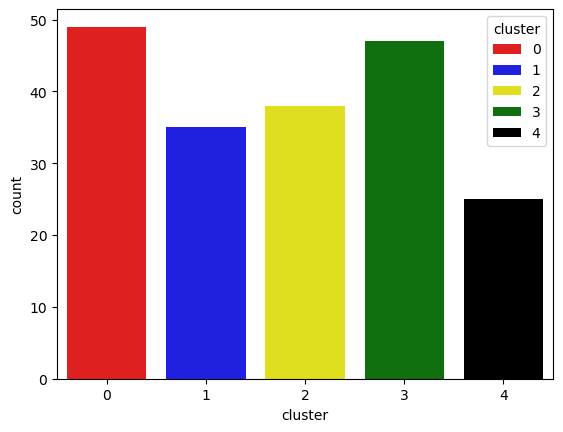

In [39]:
pal = ["red", "blue", "yellow", "green", "black"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

In [40]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

         Gender        Age  Annual Income (k$)  Spending Score (1-100)  \
cluster                                                                  
0           0.0  49.367347           55.367347               36.244898   
1           0.0  30.057143           79.000000               65.457143   
2           1.0  28.105263           58.342105               71.315789   
3           1.0  49.808511           60.829787               29.446809   
4           0.0  26.760000           31.680000               63.240000   

         Cluster  
cluster           
0            0.0  
1            1.0  
2            2.0  
3            3.0  
4            4.0  
